# 💉 Gemma-4 QLoRA Training + Inference & Evaluation
## VaccineNLP Thesis — Kiến trúc Gemma-4 Teacher (XAI)

**MSSV:** 2211090016 | **Môi trường:** Kaggle T4 GPU | **Framework:** Unsloth

### 📋 Workflow notebook (2 Phase):
- **Phase A** — QLoRA Fine-tuning: Huấn luyện Gemma-4 4B với dữ liệu Silver
- **Phase B** — Inference & Evaluation: Đánh giá trên Gold Test Set (186 mẫu)

> ✅ **Notebook này tương thích với chế độ "Save & run all" của Kaggle.**
> Toàn bộ notebook chạy trên **2x T4 GPU (16GB)** — không cần restart thủ công.


In [1]:
# [CELL 1] Cài đặt Unsloth & Xử lý Numpy
# ✅ FIX: Di chuyển pip install lên đầu tiên để tránh lỗi mid-session upgrade

import os, subprocess, sys

def run_silent(cmd):
    print(f"🏃 Running: {cmd}")
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.returncode != 0:
        print(f"⚠️  STDERR: {result.stderr[-300:]}")
    return result.returncode

# 1. Gỡ cài đặt numpy cũ nếu cần hoặc cài đè ngay lập tức
# Unsloth cần numpy>=2.0. Kaggle có 2.0.2. Chúng ta sẽ cài bản pinned để tránh upgrade lên bản dev/beta
print("📦 Cài đặt Unsloth [Kaggle-new]...")
# Sử dụng git install để có bản mới nhất fix lỗi Gemma-4
run_silent('pip install "unsloth[kaggle-new] @ git+https://github.com/unslothai/unsloth.git" --quiet')

# 2. Kiểm tra lại numpy
try:
    import numpy as np
    print(f"✅ Numpy version: {np.__version__}")
except RuntimeError as e:
    print(f"❌ Lỗi Numpy: {e}")
    print("   → Đang thử fix bằng cách reload...")
    import importlib
    importlib.reload(np)

# 3. Kiểm tra GPU
print("🖥️  GPU Info:")
subprocess.run("nvidia-smi -L", shell=True)

try:
    from unsloth import FastModel
    print("✅ Unsloth FastModel import OK")
except ImportError as e:
    print(f"❌ Import lỗi: {e}")


📦 Cài đặt Unsloth [Kaggle-new]...
🏃 Running: pip install "unsloth[kaggle-new] @ git+https://github.com/unslothai/unsloth.git" --quiet
✅ Numpy version: 2.0.2
🖥️  GPU Info:
GPU 0: Tesla T4 (UUID: GPU-d73496f7-a23a-ff7b-79c8-5c12212a91bb)
GPU 1: Tesla T4 (UUID: GPU-5100517b-6c16-f4fe-85b4-f431722fb146)
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
✅ Unsloth FastModel import OK


---
## ⚙️ Phase A — QLoRA Fine-tuning
### Bước 1: Imports & Kiểm tra GPU


In [2]:
# [CELL 2] Imports & GPU diagnostics
import os, gc, json, glob, datetime, shutil
import torch
from huggingface_hub import login, HfApi
from datasets import load_dataset
from unsloth import FastModel
from unsloth.chat_templates import get_chat_template, train_on_responses_only
from trl import SFTTrainer, SFTConfig
from IPython.display import FileLink, display

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

# GPU info
if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    total_gb = props.total_memory / 1e9
    print(f"🖥️  GPU: {props.name}")
    print(f"💾 VRAM: {total_gb:.1f} GB")
    print(f"🔢 CUDA: {torch.version.cuda}")
    print(f"⚡ BF16: {'✅' if torch.cuda.is_bf16_supported() else '❌ (dùng FP16)'}")
    if total_gb < 14:
        print("⚠️  CẢNH BÁO: VRAM < 14GB — có thể OOM khi train")
else:
    raise RuntimeError("❌ Không tìm thấy GPU — Vui lòng bật GPU T4 trong Kaggle Settings")

🖥️  GPU: Tesla T4
💾 VRAM: 15.6 GB
🔢 CUDA: 12.8
⚡ BF16: ❌ (dùng FP16)


### Bước 2: Cấu hình tập trung

In [3]:
# [CELL 3] CẤU HÌNH TẬP TRUNG — Chỉnh sửa tại đây, KHÔNG sửa ở các cell khác

# --- Paths ---
try:
    TRAIN_PATH = glob.glob("/kaggle/input/**/train_v2_seg.jsonl", recursive=True)[0]
    TEST_PATH  = glob.glob("/kaggle/input/**/benchmark_test_set.jsonl", recursive=True)[0]
except:
    TRAIN_PATH = "/kaggle/input/datasets/inhlqunhphng/vaccinenlp-clean-data/05_model_ready/train_v2_seg.jsonl"
    TEST_PATH  = "/kaggle/input/datasets/inhlqunhphng/vaccinenlp-clean-data/03_processed/benchmark_test_set.jsonl"

MODELS_SAVE_DIR = "/kaggle/working/gemma_qlora_xai"
INFERENCE_OUT   = "/kaggle/working/gemma_inference_results_v2.jsonl"
RESULTS_JSON    = "/kaggle/working/gemma_benchmark_results.json"
HF_REPO_ID      = "quynhphuong1209/gemma-4-E4B-unsloth-vaccine-xai"

# --- Model ---
BASE_MODEL      = "unsloth/gemma-4-E4B-it"
MAX_SEQ_LEN     = 1024
LOAD_IN_4BIT    = True

# --- LoRA ---
LORA_R          = 16
LORA_ALPHA      = 16
LORA_DROPOUT    = 0.0

# --- Training ---
BATCH_SIZE      = 2
GRAD_ACCUM      = 4
WARMUP_STEPS    = 10
TRAIN_EPOCHS    = 2
LEARNING_RATE   = 2e-4
WEIGHT_DECAY    = 0.01
LR_SCHEDULER    = "cosine"
SEED            = 42

# --- Label Maps ---
MISINFO_MAP  = {0: 'Không liên quan', 1: 'Tin giả', 2: 'Chính xác'}
STANCE_MAP   = {0: 'Ủng hộ', 1: 'Phản đối', 2: 'Trung lập', 3: 'Không rõ'}
SENTIMENT_MAP= {0: 'Tiêu cực', 1: 'Trung tính', 2: 'Tích cực'}

os.makedirs(MODELS_SAVE_DIR, exist_ok=True)
print("✅ Config loaded")
print(f"   Train  : {TRAIN_PATH}")
print(f"   Test   : {TEST_PATH}")
print(f"   Output : {MODELS_SAVE_DIR}")
print(f"   HF repo: {HF_REPO_ID}")

✅ Config loaded
   Train  : /kaggle/input/datasets/inhlqunhphng/vaccinenlp-clean-data/05_model_ready/train_v2_seg.jsonl
   Test   : /kaggle/input/datasets/inhlqunhphng/vaccinenlp-clean-data/03_processed/benchmark_test_set.jsonl
   Output : /kaggle/working/gemma_qlora_xai
   HF repo: quynhphuong1209/gemma-4-E4B-unsloth-vaccine-xai


### Bước 3: Load Gemma-4 + LoRA Config

In [4]:
# [CELL 4] Load Gemma-4 E4B + LoRA adapter
model, tokenizer = FastModel.from_pretrained(
    model_name     = BASE_MODEL,
    max_seq_length = MAX_SEQ_LEN,
    dtype          = None,
    load_in_4bit   = LOAD_IN_4BIT,
)

model = FastModel.get_peft_model(
    model,
    finetune_vision_layers     = False,
    finetune_language_layers   = True,
    finetune_attention_modules = True,
    finetune_mlp_modules       = True,
    r                          = LORA_R,
    lora_alpha                 = LORA_ALPHA,
    lora_dropout               = LORA_DROPOUT,
    bias                       = "none",
    use_gradient_checkpointing = "unsloth",
    random_state               = SEED,
)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model loaded: {BASE_MODEL}")
print(f"   Total params    : {total_params/1e6:.1f}M")
print(f"   Trainable params: {trainable_params/1e6:.1f}M ({100*trainable_params/total_params:.2f}%)")

==((====))==  Unsloth 2026.5.2: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/203 [00:00<?, ?B/s]

processor_config.json: 0.00B [00:00, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/32.2M [00:00<?, ?B/s]

✅ Model loaded: unsloth/gemma-4-E4B-it
   Total params    : 6335.5M
   Trainable params: 36.7M (0.58%)


### Bước 4: Chuẩn bị Dataset & Format Prompt

In [5]:
# [CELL 5] Dataset preparation + prompt formatting
from datasets import load_dataset

def get_chat_template(tokenizer, chat_template="gemma-4"):
    """Áp dụng chat template cho tokenizer."""
    if chat_template == "gemma-4":
        # Gemma-4 style template
        tokenizer.chat_template = "{% for message in messages %}" \
        "{% if message['role'] == 'user' %}" \
        "<start_of_turn>user\n{{ message['content'] }}<end_of_turn>\n" \
        "{% elif message['role'] == 'assistant' %}" \
        "<start_of_turn>model\n{{ message['content'] }}<end_of_turn>\n" \
        "{% endif %}" \
        "{% endfor %}"
    elif chat_template == "llama3":
        # Llama 3 style template
        tokenizer.chat_template = "{% for message in messages %}" \
        "{% if message['role'] == 'user' %}" \
        "<|start_header_id|>user<|end_header_id|>\n\n{{ message['content'] }}<|eot_id|>" \
        "{% elif message['role'] == 'assistant' %}" \
        "<|start_header_id|>assistant<|end_header_id|>\n\n{{ message['content'] }}<|eot_id|>" \
        "{% endif %}" \
        "{% endfor %}"
    else:
        # Mặc định sử dụng template của tokenizer
        pass
    
    return tokenizer

# Áp dụng chat template cho tokenizer từ CELL 4
tokenizer = get_chat_template(tokenizer, chat_template="gemma-4")

def format_prompt(row):
    """Chuyển row JSONL → conversation format cho Gemma-4 (XAI pattern)."""
    text      = row.get('text_cleaned') or row.get('text') or ''
    reasoning = row.get('llm_reasoning', 'Phân tích dựa trên ngữ cảnh.')
    ids       = row.get('standardized_ids') or [0, 2, 1]

    misinfo_label = MISINFO_MAP.get(ids[0], 'Không liên quan')
    stance_label  = STANCE_MAP.get(ids[1], 'Không rõ')
    senti_label   = SENTIMENT_MAP.get(ids[2], 'Trung tính')

    convo = [
        {
            "role": "user",
            "content": (
                f"Phân tích nội dung sau về vaccine:\n\n\"{text}\"\n\n"
                "Hãy:\n"
                "1. Lý luận từng bước về nội dung\n"
                "2. Phân loại theo 3 chiều:\n"
                "   - Misinformation: Không liên quan / Tin giả / Chính xác\n"
                "   - Stance: Ủng hộ / Phản đối / Trung lập / Không rõ\n"
                "   - Sentiment: Tiêu cực / Trung tính / Tích cực"
            )
        },
        {
            "role": "assistant",
            "content": (
                f"Lý luận:\n{reasoning}\n\n"
                f"Kết quả:\n"
                f"- Misinformation: {misinfo_label}\n"
                f"- Stance: {stance_label}\n"
                f"- Sentiment: {senti_label}"
            )
        }
    ]
    return tokenizer.apply_chat_template(convo, tokenize=False)

# Load dataset
raw_ds = load_dataset("json", data_files={"train": TRAIN_PATH}, split="train")
split  = raw_ds.train_test_split(test_size=0.1, seed=SEED)
train_ds = split["train"].map(lambda r: {"text": format_prompt(r)}, num_proc=2)
eval_ds  = split["test"].map(lambda r: {"text": format_prompt(r)}, num_proc=2)

print(f"✅ Dataset ready — Train: {len(train_ds)}, Eval: {len(eval_ds)}")

Generating train split: 0 examples [00:00, ? examples/s]

Map (num_proc=2):   0%|          | 0/1503 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/167 [00:00<?, ? examples/s]

✅ Dataset ready — Train: 1503, Eval: 167


### Bước 5: Huấn luyện QLoRA

In [6]:
# [CELL 6] Với train_on_responses_only - ĐÃ SỬA PATTERN ĐÚNG
from trl import SFTTrainer, SFTConfig
from unsloth import train_on_responses_only
import torch

trainer = SFTTrainer(
    model         = model,
    tokenizer     = tokenizer,
    train_dataset = train_ds,
    eval_dataset  = eval_ds,
    args = SFTConfig(
        output_dir                  = MODELS_SAVE_DIR,
        dataset_text_field          = "text",
        max_length                  = MAX_SEQ_LEN,
        per_device_train_batch_size = BATCH_SIZE,
        per_device_eval_batch_size  = 1,
        gradient_accumulation_steps = GRAD_ACCUM,
        eval_accumulation_steps     = 1,
        warmup_steps                = WARMUP_STEPS,
        num_train_epochs            = TRAIN_EPOCHS,
        learning_rate               = LEARNING_RATE,
        weight_decay                = WEIGHT_DECAY,
        lr_scheduler_type           = LR_SCHEDULER,
        fp16                        = not torch.cuda.is_bf16_supported(),
        bf16                        = torch.cuda.is_bf16_supported(),
        logging_steps               = 10,
        eval_strategy               = "epoch",
        save_strategy               = "epoch",
        load_best_model_at_end      = True,
        seed                        = SEED,
        report_to                   = "none",
    ),
)

# SỬA pattern đúng với Gemma template
trainer = train_on_responses_only(
    trainer,
    instruction_part = "<end_of_turn>\n<start_of_turn>user\n",
    response_part    = "<end_of_turn>\n<start_of_turn>model\n",
)

print("🚀 Bắt đầu huấn luyện...")
train_result = trainer.train()
print(f"✅ Huấn luyện hoàn tất!")
print(f"   Loss cuối: {train_result.training_loss:.4f}")

# Lưu model
trainer.save_model(f"{MODELS_SAVE_DIR}/final_model")
tokenizer.save_pretrained(f"{MODELS_SAVE_DIR}/final_model")
print(f"✅ Model đã lưu: {MODELS_SAVE_DIR}/final_model")

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/1503 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/167 [00:00<?, ? examples/s]

Map (num_proc=8):   0%|          | 0/1503 [00:00<?, ? examples/s]

Filter (num_proc=8):   0%|          | 0/1503 [00:00<?, ? examples/s]

Unsloth: Removed 59 out of 1503 samples from train_dataset where all labels were -100 (no response found after truncation). This prevents NaN loss during training.


...

Epoch,Training Loss,Validation Loss
1,0.007190,1.194471
2,0.004775,1.250940


Unsloth: Not an error, but Gemma4ForConditionalGeneration does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/gemma_qlora_xai/checkpoint-181/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/gemma_qlora_xai/checkpoint-362/tokenizer_config.json.


✅ Huấn luyện hoàn tất!
   Loss cuối: 0.0819


Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/gemma_qlora_xai/final_model/tokenizer_config.json.


✅ Model đã lưu: /kaggle/working/gemma_qlora_xai/final_model


### Bước 6: Lưu & Upload lên HuggingFace Hub

In [7]:
# [CELL 7] Nén model + push HuggingFace Hub
# ✅ FIX: HF push được wrap trong try/except — Phase B không phụ thuộc vào push thành công

# --- Nén để download ---
print("📦 Nén model để tải về...")
shutil.make_archive('/kaggle/working/gemma_vaccine_model', 'zip', f'{MODELS_SAVE_DIR}/final_model')
print("✅ Đã tạo: /kaggle/working/gemma_vaccine_model.zip")
display(FileLink('/kaggle/working/gemma_vaccine_model.zip'))

# --- Push lên HuggingFace Hub (không bắt buộc) ---
try:
    from kaggle_secrets import UserSecretsClient
    VaccineNLP_TOKEN = UserSecretsClient().get_secret("VaccineNLP")
    if VaccineNLP_TOKEN:
        login(token=VaccineNLP_TOKEN, add_to_git_credential=False)
        api = HfApi()
        api.upload_folder(
            folder_path = f"{MODELS_SAVE_DIR}/final_model",
            repo_id     = HF_REPO_ID,
            repo_type   = "model",
        )
        print(f"✅ Pushed lên HuggingFace: {HF_REPO_ID}")
    else:
        print("⚠️  HF_TOKEN rỗng — bỏ qua push")
except Exception as e:
    print(f"⚠️  HF push thất bại (không ảnh hưởng Phase B): {e}")

print(f"\n📁 Model local: {MODELS_SAVE_DIR}/final_model")

📦 Nén model để tải về...
✅ Đã tạo: /kaggle/working/gemma_vaccine_model.zip


/kaggle/working/gemma_vaccine_model.zip

⚠️  HF push thất bại (không ảnh hưởng Phase B): Invalid user token.

📁 Model local: /kaggle/working/gemma_qlora_xai/final_model


---
## 🔄 VRAM Cleanup — Bắt buộc giữa Phase A và Phase B

> Giải phóng VRAM trước khi load model inference. Bỏ qua bước này sẽ gây **OOM error**.


In [8]:
# [CELL 8] ⚠️ BẮT BUỘC CHẠY trước Phase B
# ✅ FIX: Dùng globals() thay dir() — đáng tin cậy hơn khi "Save & run all"

print("🔄 Giải phóng VRAM...")

_to_delete = ['trainer', 'train_ds', 'eval_ds', 'model', 'tokenizer']
for _var in _to_delete:
    if _var in globals():
        del globals()[_var]
        print(f"   🗑️  Đã xóa: {_var}")

gc.collect()
torch.cuda.empty_cache()
torch.cuda.reset_peak_memory_stats()

allocated = torch.cuda.memory_allocated() / 1e9
reserved  = torch.cuda.memory_reserved()  / 1e9
print(f"\n✅ VRAM sau cleanup:")
print(f"   Allocated: {allocated:.2f} GB")
print(f"   Reserved:  {reserved:.2f} GB")
print("\n➡️  Sẵn sàng chạy Phase B — Inference & Evaluation")

🔄 Giải phóng VRAM...
   🗑️  Đã xóa: trainer
   🗑️  Đã xóa: train_ds
   🗑️  Đã xóa: eval_ds
   🗑️  Đã xóa: model
   🗑️  Đã xóa: tokenizer

✅ VRAM sau cleanup:
   Allocated: 7.02 GB
   Reserved:  7.11 GB

➡️  Sẵn sàng chạy Phase B — Inference & Evaluation


---
## 📊 Phase B — Inference & Evaluation
### Đánh giá Gemma-4 XAI trên Gold Test Set (186 mẫu)

Model được load **trực tiếp từ local** (`/kaggle/working/gemma_qlora_xai/final_model`).
Không phụ thuộc vào HuggingFace push — an toàn khi chạy tự động.


### Bước 7: Load Model cho Inference

In [9]:
# [CELL 9] Load model từ LOCAL — không cần HF Hub
# ✅ FIX CHÍNH: Dùng model vừa train trong cùng session
#    → Không phụ thuộc vào HF push thành công
#    → Tốc độ load nhanh hơn (~5x so với download từ Hub)

import torch, json, gc, glob, os
from tqdm import tqdm
from unsloth import FastModel
from unsloth.chat_templates import get_chat_template

LOCAL_MODEL_PATH = f"{MODELS_SAVE_DIR}/final_model"

if not os.path.exists(LOCAL_MODEL_PATH):
    raise FileNotFoundError(
        f"❌ Không tìm thấy model tại: {LOCAL_MODEL_PATH}\n"
        f"   Phase A phải chạy thành công trước."
    )

model, tokenizer = FastModel.from_pretrained(
    model_name     = LOCAL_MODEL_PATH,
    max_seq_length = MAX_SEQ_LEN,
    load_in_4bit   = LOAD_IN_4BIT,
)
FastModel.for_inference(model)
tokenizer = get_chat_template(tokenizer, chat_template="gemma-4")

allocated = torch.cuda.memory_allocated() / 1e9
print(f"✅ Model loaded từ local: {LOCAL_MODEL_PATH}")
print(f"💾 VRAM used: {allocated:.2f} GB")

==((====))==  Unsloth 2026.5.2: Fast Gemma4 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/2130 [00:00<?, ?it/s]

✅ Model loaded từ local: /kaggle/working/gemma_qlora_xai/final_model
💾 VRAM used: 8.96 GB


### Bước 8: Prompt Builder & Output Parser

In [10]:
# [CELL 10] Reverse label maps + build_prompt + parse_output

REV_MISINFO = {
    'không liên quan': 0, 'khong lien quan': 0, 'not relevant': 0, 'không có': 0,
    'tin giả': 1, 'tin gia': 1, 'sai lệch': 1, 'misinformation': 1,
    'chính xác': 2, 'chinh xac': 2, 'accurate': 2, 'no misinformation': 2,
}
REV_STANCE = {
    'ủng hộ': 0, 'ung ho': 0, 'support': 0, 'pro-vaccine': 0,
    'phản đối': 1, 'phan doi': 1, 'oppose': 1, 'anti-vaccine': 1,
    'trung lập': 2, 'trung lap': 2, 'neutral': 2,
    'không rõ': 3, 'khong ro': 3, 'unknown': 3, 'không xác định': 3,
}
REV_SENTIMENT = {
    'tiêu cực': 0, 'tieu cuc': 0, 'negative': 0,
    'trung tính': 1, 'trung tinh': 1, 'neutral': 1,
    'tích cực': 2, 'tich cuc': 2, 'positive': 2,
}

def build_prompt(text):
    return [{
        "role": "user",
        "content": (
            f"Phân tích nội dung sau về vaccine:\n\n\"{text}\"\n\n"
            "Hãy:\n"
            "1. Lý luận từng bước về nội dung\n"
            "2. Phân loại theo 3 chiều:\n"
            "   - Misinformation: Không liên quan / Tin giả / Chính xác\n"
            "   - Stance: Ủng hộ / Phản đối / Trung lập / Không rõ\n"
            "   - Sentiment: Tiêu cực / Trung tính / Tích cực"
        )
    }]

def parse_output(text):
    """Parse output → (misinfo_idx, stance_idx, sentiment_idx, parse_ok)."""
    text_l = text.lower()
    lines  = [l.strip() for l in text_l.split('\n')]

    def find_label(rev_map, prefix):
        for line in lines:
            if prefix in line:
                for key, val in rev_map.items():
                    if key in line:
                        return val, True
        return -1, False

    m, m_ok  = find_label(REV_MISINFO,   'misinformation:')
    st, s_ok = find_label(REV_STANCE,    'stance:')
    se, e_ok = find_label(REV_SENTIMENT, 'sentiment:')

    parse_ok = m_ok and s_ok and e_ok
    return m, st, se, parse_ok

print("✅ Parser ready — 4 nhãn stance đầy đủ (Ủng hộ/Phản đối/Trung lập/Không rõ)")

✅ Parser ready — 4 nhãn stance đầy đủ (Ủng hộ/Phản đối/Trung lập/Không rõ)


### Bước 9: Inference Loop (186 Gold Test Samples)

In [11]:
# [CELL 11] Inference loop — lưu progressive JSONL
# Resume support: bỏ qua samples đã xử lý nếu Kaggle timeout

found = glob.glob('/kaggle/input/**/benchmark_test_set.jsonl', recursive=True)
TEST_PATH_INF = found[0] if found else TEST_PATH

with open(TEST_PATH_INF, 'r', encoding='utf-8') as fh:
    test_data = [json.loads(l) for l in fh]

print(f'📦 Loaded {len(test_data)} samples từ: {TEST_PATH_INF}')
print(f'💾 Kết quả sẽ lưu tại: {INFERENCE_OUT}')

# Resume support
done_ids = set()
if os.path.exists(INFERENCE_OUT):
    with open(INFERENCE_OUT) as f:
        for line in f:
            try: done_ids.add(json.loads(line)['id'])
            except: pass
    print(f'♻️  Resume: đã có {len(done_ids)} samples — bỏ qua')

model.config.use_cache = True

with open(INFERENCE_OUT, 'a', encoding='utf-8') as out_f:
    for row in tqdm(test_data, desc="Inference"):
        sid = row.get('id', row.get('post_id', ''))
        if sid in done_ids:
            continue

        text = row.get('text_cleaned') or row.get('text') or ''
        msgs = build_prompt(text)
        prompt_str = tokenizer.apply_chat_template(
            msgs, tokenize=False, add_generation_prompt=True
        )
        forced_str = prompt_str + "Lý luận:\n"

        inputs = tokenizer(text=forced_str, return_tensors="pt").to("cuda")
        with torch.no_grad():
            out = model.generate(
                **inputs,
                max_new_tokens  = 1024,
                temperature     = 0.1,
                do_sample       = True,
                repetition_penalty = 1.1,
            )

        generated = tokenizer.decode(
            out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True
        )
        m, st, se, parse_ok = parse_output(generated)

        ids = row.get('standardized_ids') or [-1, -1, -1]
        record = {
            'id':       sid,
            'true_m':   ids[0] if len(ids) > 0 else -1,
            'true_st':  ids[1] if len(ids) > 1 else -1,
            'true_se':  ids[2] if len(ids) > 2 else -1,
            'pred_m':   m,
            'pred_st':  st,
            'pred_se':  se,
            'parse_ok': parse_ok,
            'reasoning': generated[:500],
        }
        out_f.write(json.dumps(record, ensure_ascii=False) + '\n')
        out_f.flush()

print(f'\n✅ Inference hoàn tất — {INFERENCE_OUT}')

📦 Loaded 186 samples từ: /kaggle/input/datasets/inhlqunhphng/vaccinenlp-clean-data/03_processed/benchmark_test_set.jsonl
💾 Kết quả sẽ lưu tại: /kaggle/working/gemma_inference_results_v2.jsonl


Inference: 100%|██████████| 186/186 [8:22:02<00:00, 161.95s/it]


✅ Inference hoàn tất — /kaggle/working/gemma_inference_results_v2.jsonl


### Bước 10: Evaluation — Macro F1 & Classification Report

In [12]:
# [CELL 12] Classification Report + Macro F1
from sklearn.metrics import classification_report, f1_score, confusion_matrix
import numpy as np

records = []
with open(INFERENCE_OUT, 'r') as f:
    for line in f:
        try: records.append(json.loads(line))
        except: pass

print(f'📊 Đánh giá trên {len(records)} samples (target: 186)\n')

parse_fails = sum(1 for r in records if not r['parse_ok'])
print(f'⚠️  Parse Failure: {parse_fails}/{len(records)} = {parse_fails/len(records)*100:.1f}%')
print('='*60)

results = {}
task_configs = [
    ('misinfo',   'true_m',  'pred_m',  ['Không liên quan', 'Tin giả', 'Chính xác']),
    ('stance',    'true_st', 'pred_st', ['Ủng hộ', 'Phản đối', 'Trung lập', 'Không rõ']),
    ('sentiment', 'true_se', 'pred_se', ['Tiêu cực', 'Trung tính', 'Tích cực']),
]

for task, tk, pk, labels in task_configs:
    y_true = [r[tk] for r in records if r[tk] != -1 and r[pk] != -1]
    y_pred = [r[pk] for r in records if r[tk] != -1 and r[pk] != -1]
    if not y_true:
        print(f'⚠️  {task}: không có dữ liệu hợp lệ')
        continue
    macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    results[task] = {'macro_f1': round(macro_f1, 4)}
    print(f'\n📌 Task: {task.upper()}')
    print(classification_report(
        y_true, y_pred,
        target_names=labels[:max(y_true+y_pred)+1] if max(y_true+y_pred) < len(labels) else labels,
        zero_division=0
    ))

print('\n' + '='*60)
print('📊 MACRO F1 SUMMARY:')
for task, res in results.items():
    print(f'   {task:<12}: {res["macro_f1"]:.4f}')

📊 Đánh giá trên 186 samples (target: 186)

⚠️  Parse Failure: 110/186 = 59.1%

📌 Task: MISINFO
                 precision    recall  f1-score   support

Không liên quan       0.00      0.00      0.00         0
        Tin giả       0.06      0.50      0.10         4
      Chính xác       0.00      0.00      0.00        73

       accuracy                           0.03        77
      macro avg       0.02      0.17      0.03        77
   weighted avg       0.00      0.03      0.01        77


📌 Task: STANCE
              precision    recall  f1-score   support

      Ủng hộ       0.31      0.57      0.40        23
    Phản đối       0.80      0.67      0.73        12
   Trung lập       0.70      0.30      0.42        46
    Không rõ       0.00      0.00      0.00         0

    accuracy                           0.43        81
   macro avg       0.45      0.38      0.39        81
weighted avg       0.60      0.43      0.46        81


📌 Task: SENTIMENT
              precision    recall

### Bước 11: Export Benchmark Results JSON

In [13]:
# [CELL 13] Export kết quả ra JSON
import datetime

benchmark = {
    'model':               'gemma-4-4b-xai',
    'hf_repo':             HF_REPO_ID,
    'timestamp':           datetime.datetime.now().isoformat() + 'Z',
    'total_samples':       len(records),
    'parse_failure_rate':  round(parse_fails / len(records), 4),
    'misinfo':             results.get('misinfo',   {}),
    'stance':              results.get('stance',    {}),
    'sentiment':           results.get('sentiment', {}),
}

with open(RESULTS_JSON, 'w', encoding='utf-8') as f:
    json.dump(benchmark, f, indent=2, ensure_ascii=False)

print(f'✅ Kết quả đã lưu: {RESULTS_JSON}')
print(json.dumps(benchmark, indent=2, ensure_ascii=False))

✅ Kết quả đã lưu: /kaggle/working/gemma_benchmark_results.json
{
  "model": "gemma-4-4b-xai",
  "hf_repo": "quynhphuong1209/gemma-4-E4B-unsloth-vaccine-xai",
  "timestamp": "2026-05-11T21:57:30.132993Z",
  "total_samples": 186,
  "parse_failure_rate": 0.5914,
  "misinfo": {
    "macro_f1": 0.0342
  },
  "stance": {
    "macro_f1": 0.3879
  },
  "sentiment": {
    "macro_f1": 0.6336
  }
}


### Bước 12: Confusion Matrix

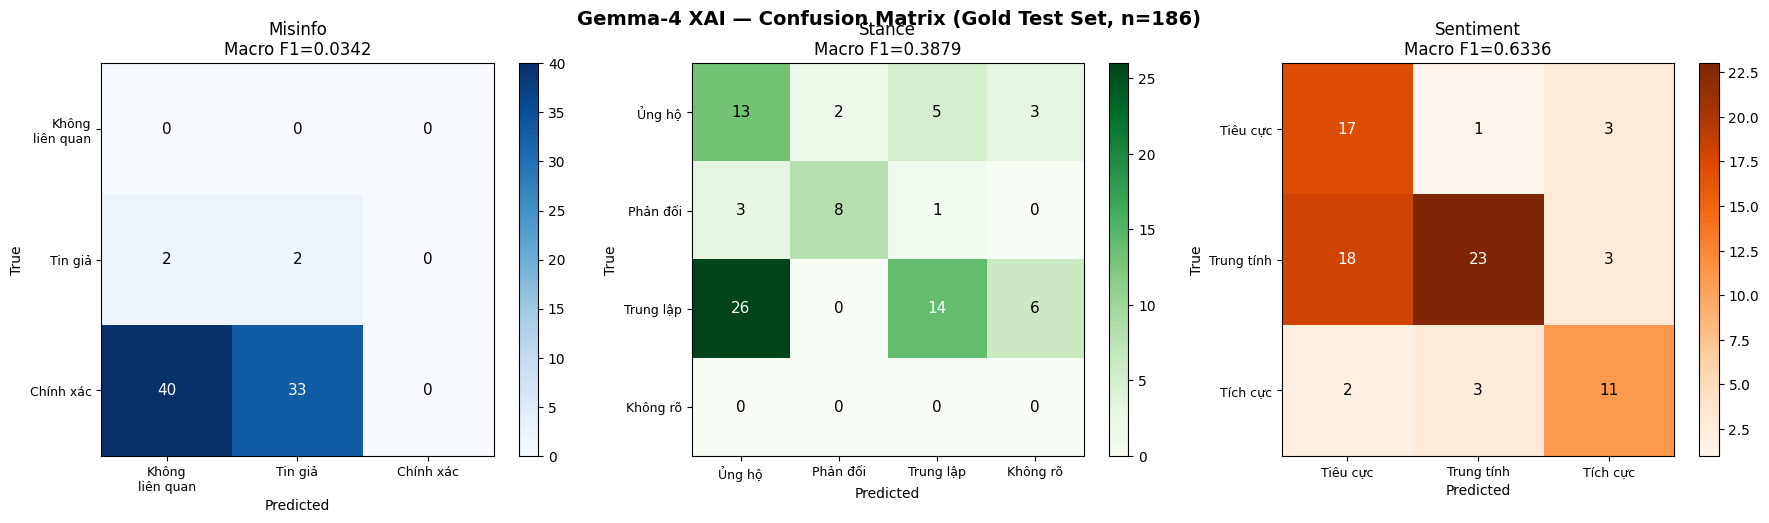

✅ Đã lưu: /kaggle/working/confusion_matrix.png


In [14]:
# [CELL 14] Confusion matrix cho 3 tasks
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Gemma-4 XAI — Confusion Matrix (Gold Test Set, n=186)', fontsize=14, fontweight='bold')

task_plot_configs = [
    ('misinfo',   'true_m',  'pred_m',  ['Không\nliên quan', 'Tin giả', 'Chính xác'],              'Blues'),
    ('stance',    'true_st', 'pred_st', ['Ủng hộ', 'Phản đối', 'Trung lập', 'Không rõ'],            'Greens'),
    ('sentiment', 'true_se', 'pred_se', ['Tiêu cực', 'Trung tính', 'Tích cực'],                     'Oranges'),
]

for ax, (task, tk, pk, labels, cmap) in zip(axes, task_plot_configs):
    y_true = [r[tk] for r in records if r[tk] != -1 and r[pk] != -1]
    y_pred = [r[pk] for r in records if r[tk] != -1 and r[pk] != -1]
    n = len(labels)
    cm = confusion_matrix(y_true, y_pred, labels=list(range(n)))
    im = ax.imshow(cm, cmap=cmap)
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(labels, fontsize=9); ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{task.capitalize()}\nMacro F1={results.get(task,{}).get("macro_f1","N/A")}')
    for i in range(n):
        for j in range(n):
            ax.text(j, i, str(cm[i,j]), ha='center', va='center', fontsize=11,
                    color='white' if cm[i,j] > cm.max()/2 else 'black')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig('/kaggle/working/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Đã lưu: /kaggle/working/confusion_matrix.png")

### Bước 13: So sánh với PhoBERT-v2 & XLM-R

In [15]:
# [CELL 15] Bảng so sánh 3 mô hình
PHOBERT_F1 = {'misinfo': 0.4547, 'stance': 0.6608, 'sentiment': 0.7325}
XLMR_F1    = {'misinfo': 0.4572, 'stance': 0.6247, 'sentiment': 0.6918}
GEMMA_F1   = {k: results[k]['macro_f1'] for k in results}

print('='*65)
print('📊 BENCHMARK COMPARISON — Macro F1 Score (Gold Test Set, n=186)')
print('='*65)
print(f"{'Model':<25} {'Misinfo':>10} {'Stance':>10} {'Sentiment':>12} {'Avg':>8}")
print('-'*65)

comparison = [
    ('XLM-R-v1 (Baseline)',     XLMR_F1),
    ('PhoBERT-v2 (Classifier)', PHOBERT_F1),
    ('Gemma-4 4B (XAI Engine)', GEMMA_F1),
]
for name, f1 in comparison:
    avg = sum(f1.values()) / len(f1) if len(f1) > 0 else 0
    print(f"{name:<25} {f1.get('misinfo',0):>10.4f} {f1.get('stance',0):>10.4f} {f1.get('sentiment',0):>12.4f} {avg:>8.4f}")

print('='*65)

📊 BENCHMARK COMPARISON — Macro F1 Score (Gold Test Set, n=186)
Model                        Misinfo     Stance    Sentiment      Avg
-----------------------------------------------------------------
XLM-R-v1 (Baseline)           0.4572     0.6247       0.6918   0.5912
PhoBERT-v2 (Classifier)       0.4547     0.6608       0.7325   0.6160
Gemma-4 4B (XAI Engine)       0.0342     0.3879       0.6336   0.3519


### (Optional) Bước 14: Quick Test — Phân tích mẫu thực

In [16]:
# [CELL 16] Test nhanh với 3 mẫu điển hình
test_samples = [
    ("Ko tiêm mũi nào hết. Cha mẹ thời nay bị doạ cho sợ hãi, chả có tác dụng gì còn gây hại.",
     "Tin giả | Phản đối | Tiêu cực"),
    ("Mình vừa tiêm xong mũi 2, bs bảo vx an toàn, không lo phản ứng phụ.",
     "Chính xác | Ủng hộ | Tích cực"),
    ("Bé nhà tôi tiêm 5 trong 1 xong bị sốt 38.5, có sao không ạ?",
     "Không liên quan | Không rõ | Tiêu cực"),
]

model.config.use_cache = True
print('🧪 QUICK TEST — 3 mẫu điển hình\n')

for i, (text, expected) in enumerate(test_samples):
    msgs = build_prompt(text)
    prompt_str = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    forced_str = prompt_str + "Lý luận:\n"
    inputs = tokenizer(text=forced_str, return_tensors="pt").to("cuda")
    with torch.no_grad():
        out = model.generate(**inputs, max_new_tokens=200, temperature=0.1, do_sample=True)
    generated = tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    m, st, se, ok = parse_output(generated)

    label_str = f"{MISINFO_MAP.get(m,'?')} | {STANCE_MAP.get(st,'?')} | {SENTIMENT_MAP.get(se,'?')}"
    print(f'[{i+1}] {text[:70]}...')
    print(f'  Expected : {expected}')
    print(f'  Predicted: {label_str} (parse_ok={ok})')
    print(f'  Reasoning: {generated[:200]}...')
    print()

🧪 QUICK TEST — 3 mẫu điển hình

[1] Ko tiêm mũi nào hết. Cha mẹ thời nay bị doạ cho sợ hãi, chả có tác dụn...
  Expected : Tin giả | Phản đối | Tiêu cực
  Predicted: ? | ? | ? (parse_ok=False)
  Reasoning: Nội dung được cung cấp là: "Ko tiêm mũi nào hết. Cha mẹ thời nay bị doạ cho sợ hãi, chả có tác dụng gì còn gây hại."

**1. Lý luận từng bước về nội dung:**

*   **Phân tích câu nói:** Câu nói này thể ...

[2] Mình vừa tiêm xong mũi 2, bs bảo vx an toàn, không lo phản ứng phụ....
  Expected : Chính xác | Ủng hộ | Tích cực
  Predicted: ? | ? | ? (parse_ok=False)
  Reasoning: Nội dung được cung cấp là một nhận định cá nhân về trải nghiệm tiêm vaccine: "Mình vừa tiêm xong mũi 2, bs bảo vx an toàn, không lo phản ứng phụ."

**1. Lý luận từng bước về nội dung:**

*   **Phân tí...

[3] Bé nhà tôi tiêm 5 trong 1 xong bị sốt 38.5, có sao không ạ?...
  Expected : Không liên quan | Không rõ | Tiêu cực
  Predicted: Tin giả | ? | ? (parse_ok=False)
  Reasoning: 1. **Phân tích nội dung:** Câu hỏi "